In [1]:
import datetime as dt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()

import sklearn
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

os.chdir("..")
pd.set_option("display.max_columns", None)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Loading data

In [2]:
data_path = Path("data/merged/merged_preprocessed.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")
data = data.sort_values(by=["region_id", "time"])

In [3]:
data.head(3)

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-29 00:00:00+03:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,13.9,257.0,1016.0,20.0,0.0,0.0,0,21,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0,1.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-29 01:00:00+03:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,9.5,256.0,1015.8,20.0,20.7,0.0,4,21,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1,1.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-29 02:00:00+03:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,12.3,240.0,1015.3,20.0,30.6,0.0,4,21,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,2,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
data.isna().sum().sum()

np.int64(0)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 804537 entries, 0 to 804536
Columns: 106 entries, region_id to alarm_status_24h_ago
dtypes: datetime64[us, Europe/Kyiv](1), float64(57), int64(48)
memory usage: 650.6 MB


In [6]:
print(f"Percent of alarms: {data["alarm"].sum() / len(data):.2%}")

Percent of alarms: 20.80%


In [7]:
data.agg(["min", "max", "mean", "std"])

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
min,1.000000,2022-02-25 07:00:00+02:00,0.000000,-26.400000,-33.200000,8.460000,-28.400000,0.000000,0.000000,0.000000,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,-31.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.108198,3.000000,2.162327e-08,2.162327e-08,-8.000000,-3.000000,0.065127,0.207121,0.400000,2.000000,0.115810,18.000000,0.416667,2022.000000,1.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,24.000000,2026-03-11 18:00:00+02:00,1.000000,39.400000,42.200000,100.000000,24.600000,300.000000,100.000000,5.000000,90.000000,639.000000,1050.000000,75.000000,100.000000,10.000000,15.000000,22.000000,217.000000,48.000000,12.000000,64.000000,119.000000,118.000000,11.000000,10.000000,17.000000,23.000000,23.000000,23.000000,105.000000,105.000000,105.000000,118.000000,23.000000,386.000000,1414.000000,31.000000,6.000000,1.000000,113586.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,1.0,0.464887,7.000000,1.078992e+00,1.028184e+00,28.000000,3.000000,0.673703,0.500972,1.000000,3.000000,0.696373,30.000000,1.000000,2026.000000,12.000000,31.000000,23.000000,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,12.660717,2024-02-27 12:57:29.164923+02:00,0.208029,10.479989,8.979470,73.230816,5.118939,0.082661,8.033192,0.445965,11.507830,196.178952,1016.716699,13.760149,62.827260,1.401483,3.1856

In [8]:
target = "alarm"

X = data.copy()
y = X.pop(target)

# X = X.drop(columns="other_alarms_count")

In [9]:
cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend"] \
            + list(X.select_dtypes(include=["str"], exclude=["datetime"]).columns) \
            + [col for col in X.columns if col.startswith("alarm_status_") or col.startswith("isw_cluster_")]
X[cat_cols] = X[cat_cols].astype('category')

num_cols = [col for col in X.select_dtypes(include="number").columns]

print(f"Categorical columns:\n{cat_cols}")
print("-"*20)
print(f"Numerical columns:\n{num_cols}")

Categorical columns:
['hour_preciptype', 'hour_conditions', 'is_weekend', 'isw_cluster_0', 'isw_cluster_1', 'isw_cluster_2', 'isw_cluster_3', 'isw_cluster_4', 'isw_cluster_5', 'isw_cluster_6', 'isw_cluster_7', 'isw_cluster_8', 'isw_cluster_9', 'alarm_status_1h_ago', 'alarm_status_2h_ago', 'alarm_status_3h_ago', 'alarm_status_4h_ago', 'alarm_status_5h_ago', 'alarm_status_6h_ago', 'alarm_status_7h_ago', 'alarm_status_8h_ago', 'alarm_status_9h_ago', 'alarm_status_10h_ago', 'alarm_status_11h_ago', 'alarm_status_12h_ago', 'alarm_status_13h_ago', 'alarm_status_14h_ago', 'alarm_status_15h_ago', 'alarm_status_16h_ago', 'alarm_status_17h_ago', 'alarm_status_18h_ago', 'alarm_status_19h_ago', 'alarm_status_20h_ago', 'alarm_status_21h_ago', 'alarm_status_22h_ago', 'alarm_status_23h_ago', 'alarm_status_24h_ago']
--------------------
Numerical columns:
['region_id', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_windspeed', 'hour_winddir', 'hour_p

# Evaluation function with TimeSeries split

In [25]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from time import time

cat_cols = list(X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns)
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    # ('label_encode', LabelEncoder(), cat_cols),
    ('scale', StandardScaler(), num_cols),
    ("drop_cols", "drop", ["time"]),
], remainder='passthrough')


def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24*7):
    
    fold_train_scores = [[] for _ in range(n_splits)]
    fold_test_scores  = [[] for _ in range(n_splits)]

    all_y_true = []
    all_y_pred = []
    regions = sorted(X["region_id"].unique())
    training_start = time()
    
    for region_id in regions:
        unique_hours = X.loc[X.region_id == region_id, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_hours = unique_hours[train_idx]
            test_hours  = unique_hours[test_idx]

            train_mask = X["time"].isin(train_hours) & (X["region_id"] == region_id)
            test_mask  = X["time"].isin(test_hours)  & (X["region_id"] == region_id)
                   
            X_train = X[train_mask]
            y_train = y[train_mask]
            X_test  = X[test_mask]
            y_test  = y[test_mask]
    
            if len(X_test) == 0:
                print(f"Empty test set on fold {fold}!")
                print(f"test_idx = {test_idx}")
                print(f"region_id = {region_id}")
                continue
            
            pipeline.fit(X_train, y_train)
    
            y_pred_train = pipeline.predict(X_train)
            y_pred_test  = pipeline.predict(X_test)

            fold_train_scores[fold].append(f1_score(y_train, y_pred_train))
            fold_test_scores[fold].append(f1_score(y_test, y_pred_test))

            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred_test)

    fold_train_means = [np.mean(scores) for scores in fold_train_scores if scores]
    fold_test_means  = [np.mean(scores) for scores in fold_test_scores  if scores]

    print("\n------------- Per-Fold Results (mean across regions) -------------")
    for fold, (tr, te) in enumerate(zip(fold_train_means, fold_test_means)):
        print(f"  Fold {fold+1} — Train F1: {tr:.3f}  |  Test F1: {te:.3f}")

    print("\n------------- Overall -------------")
    print(f"Train F1 : {np.mean(fold_train_means):.3f} ± {np.std(fold_train_means):.3f}")
    print(f"Test  F1 : {np.mean(fold_test_means):.3f} ± {np.std(fold_test_means):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")

    scores = {
        "train_f1": fold_train_means,
        "test_f1":  fold_test_means, 
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

# Choosing best performing model

In [25]:
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models = {
    "SGD": SGDClassifier(random_state=42, shuffle=False),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(random_state=42),
}

cms = dict()

for model_name, model in models.items():
    print(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores, cm = evaluate_model(pipeline)
    cms[model_name] = cm
    
    print()

SGD

------------- Per-Fold Results (mean across regions) -------------
  Fold 1 — Train F1: 0.734  |  Test F1: 0.617
  Fold 2 — Train F1: 0.782  |  Test F1: 0.743
  Fold 3 — Train F1: 0.785  |  Test F1: 0.690
  Fold 4 — Train F1: 0.771  |  Test F1: 0.706
  Fold 5 — Train F1: 0.774  |  Test F1: 0.592

------------- Overall -------------
Train F1 : 0.769 ± 0.018
Test  F1 : 0.670 ± 0.056
Completed in: 33.18s.

DecisionTree

------------- Per-Fold Results (mean across regions) -------------
  Fold 1 — Train F1: 1.000  |  Test F1: 0.576
  Fold 2 — Train F1: 1.000  |  Test F1: 0.748
  Fold 3 — Train F1: 1.000  |  Test F1: 0.697
  Fold 4 — Train F1: 1.000  |  Test F1: 0.664
  Fold 5 — Train F1: 1.000  |  Test F1: 0.504

------------- Overall -------------
Train F1 : 1.000 ± 0.000
Test  F1 : 0.638 ± 0.087
Completed in: 65.62s.

RandomForest

------------- Per-Fold Results (mean across regions) -------------
  Fold 1 — Train F1: 1.000  |  Test F1: 0.824
  Fold 2 — Train F1: 1.000  |  Test F1: 

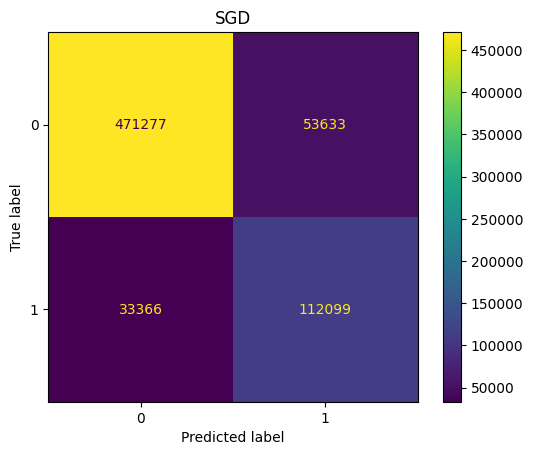

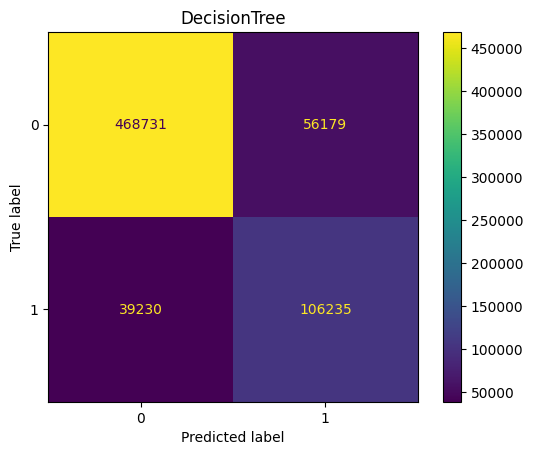

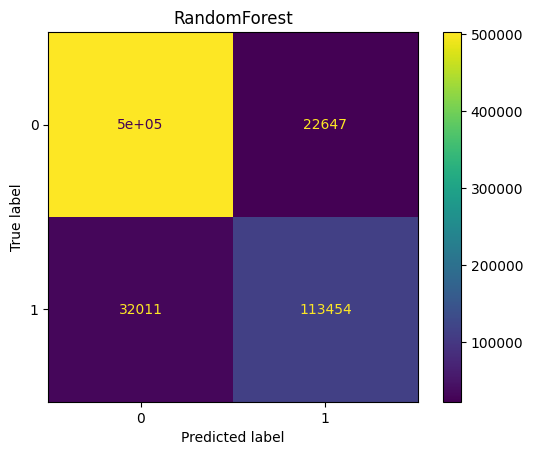

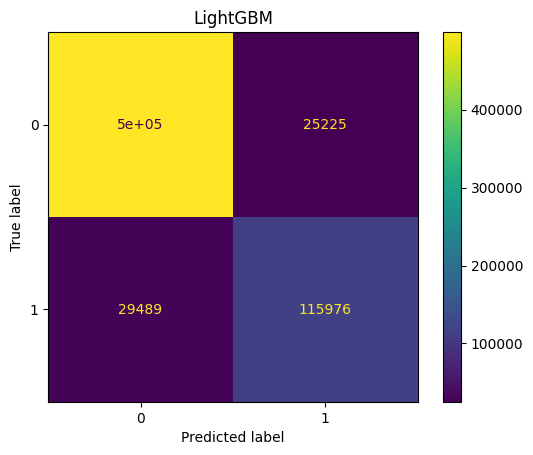

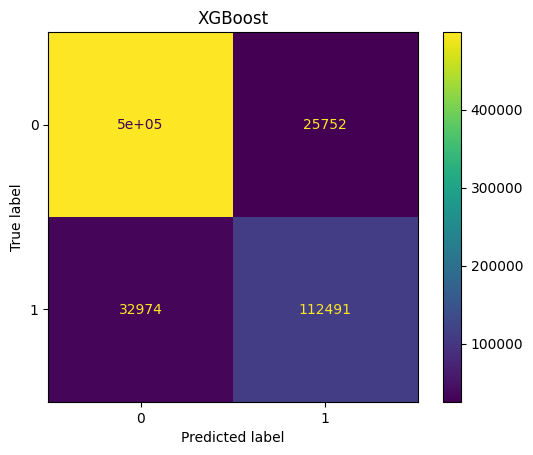

In [15]:
for model_name, cm in cms.items():
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name)
    plt.show()    

LightGBM classifier performed best so will be using it

# Parameter tunning for LGBM

In [34]:
model = LGBMClassifier(
    random_state=42,
    max_depth=6,
    num_leaves=20,
    min_child_samples=50,
    verbose=-1
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, n_splits=25, gap=24*7)


------------- Per-Fold Results (mean across regions) -------------
  Fold 1 — Train F1: 0.989  |  Test F1: 0.645
  Fold 2 — Train F1: 0.984  |  Test F1: 0.773
  Fold 3 — Train F1: 0.976  |  Test F1: 0.787
  Fold 4 — Train F1: 0.971  |  Test F1: 0.836
  Fold 5 — Train F1: 0.968  |  Test F1: 0.859
  Fold 6 — Train F1: 0.965  |  Test F1: 0.891
  Fold 7 — Train F1: 0.961  |  Test F1: 0.832
  Fold 8 — Train F1: 0.955  |  Test F1: 0.868
  Fold 9 — Train F1: 0.950  |  Test F1: 0.886
  Fold 10 — Train F1: 0.948  |  Test F1: 0.775
  Fold 11 — Train F1: 0.943  |  Test F1: 0.839
  Fold 12 — Train F1: 0.937  |  Test F1: 0.874
  Fold 13 — Train F1: 0.935  |  Test F1: 0.844
  Fold 14 — Train F1: 0.931  |  Test F1: 0.865
  Fold 15 — Train F1: 0.928  |  Test F1: 0.832
  Fold 16 — Train F1: 0.924  |  Test F1: 0.788
  Fold 17 — Train F1: 0.921  |  Test F1: 0.821
  Fold 18 — Train F1: 0.919  |  Test F1: 0.830
  Fold 19 — Train F1: 0.916  |  Test F1: 0.821
  Fold 20 — Train F1: 0.914  |  Test F1: 0.822
 

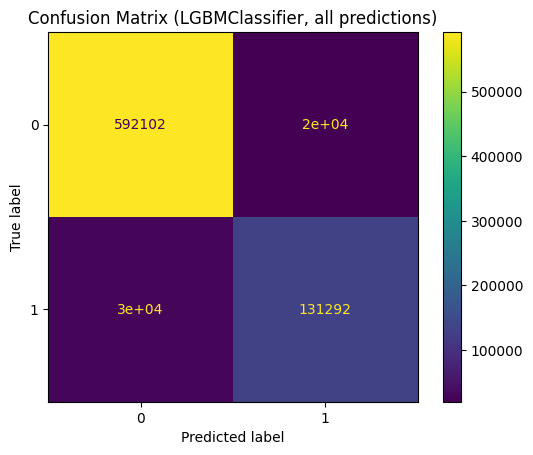

In [38]:
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (LGBMClassifier, all predictions)")
plt.show()

In [28]:
# import optuna
# from lightgbm import LGBMClassifier
# from sklearn.model_selection import cross_val_score

# def objective(trial):
#     params = {
#         "num_leaves": trial.suggest_int("num_leaves", 10, 50),
#         "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
#         "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#     }
#     model = LGBMClassifier(**params, n_estimators=300, learning_rate=0.05)

#     regions = sorted(X.region_id.unique())
#     scores = []
    
#     for region_id in regions:
#         mask = (X.region_id == region_id)
#         X_reg = X.loc[mask].drop(columns="time")
#         y_reg = y.loc[mask]
    
#         score = cross_val_score(model, X_reg, y_reg, cv=TimeSeriesSplit(n_splits=10, gap=24), scoring="f1").mean()
#         scores.append(score)

#     return np.mean(scores)

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=50)

# Top features

In [13]:
def plot_top_features(pipeline, top_n=20):
    prep_step = pipeline.named_steps["preprocessor"]
    feature_names = prep_step.get_feature_names_out()
    feature_names = [name.split("__")[-1] for name in feature_names]
    model = pipeline.named_steps["model"]
    
    if hasattr(model, "feature_importances_"):
        coefs = model.feature_importances_
    else:
        coefs = model.coef_[0]
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": coefs
    })
    
    importance_df["Abs_Weight"] = importance_df["Weight"].abs()
    
    top_20_features = importance_df.sort_values(by="Abs_Weight", ascending=False).head(top_n)
    
    plt.figure(figsize=(11, 7))
    sns.barplot(
        data=top_20_features, 
        x="Weight", 
        y="Feature", 
        hue="Feature", 
        palette="vlag", 
        legend=False
    )
    plt.title("top 20 features - Logistic Regression")
    plt.xlabel("coefficient weight (positive = increases, negative = decreases)")
    plt.ylabel("feature")
    plt.show()

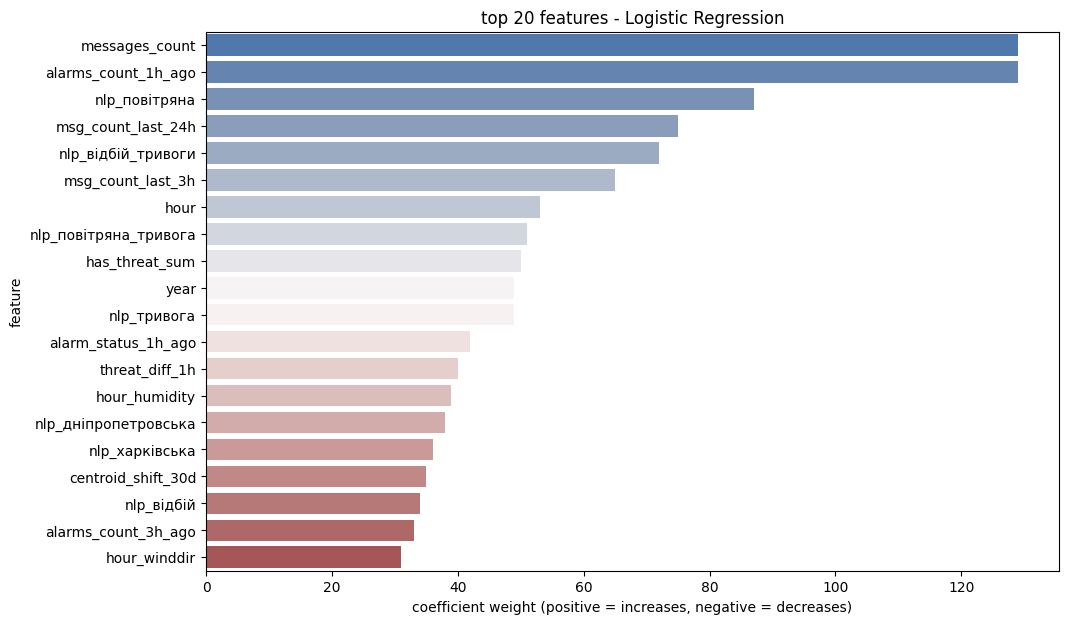

In [14]:
plot_top_features(pipeline)